# Growth Analysis Templates

This notebook consolidates reusable templates for:
- operations dashboard
- experiment report
- custom KPI monitoring
- multi-metric comparison notebooks

The goal is to reuse the same analytics layer across recurring business review workflows.

In [1]:
from pathlib import Path

import pandas as pd

from notebook_framework import (
    NotebookProject,
    ab_test_summary,
    attribution_breakdown,
    build_growth_dashboard,
    build_report_table,
    funnel_comparison,
    kpi_monitor_table,
    plot_metric_comparison,
    time_series_summary,
)

project = NotebookProject(repo_root=Path.cwd().resolve().parent.parent)
df = project.load_csv("notebook_env_demo.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,source,region,channel,visits,orders,revenue,conversion
0,2026-01-01,search,north,organic,836,71,3474.88,0.0849
1,2026-01-01,ads,north,paid,924,60,2233.92,0.0649
2,2026-01-01,social,north,social,731,32,890.48,0.0438
3,2026-01-01,email,north,email,676,74,4346.08,0.1095
4,2026-01-02,search,south,organic,786,66,3230.88,0.0840


## 1) 运营看板模板

Use this section to summarise performance by channel/source and track the trend over time.

In [2]:
summary = build_report_table(
    df,
    group_by="source",
    metrics={"visits": "visits", "orders": "orders", "revenue": "revenue"},
)
summary.head()

,source,visits,orders,revenue
0,ads,38934,2516,93690.72
1,search,34273,2899,141893.84
2,social,31396,1399,38885.68
3,email,29879,3272,192166.32


In [3]:
trend = time_series_summary(
    df,
    date_col="date",
    value_col="visits",
    group_by="source",
    freq="D",
)
trend.head()

,source,date,total_visits
0,ads,2026-01-01,924
1,ads,2026-01-02,876
2,ads,2026-01-03,1046
3,ads,2026-01-04,1263
4,ads,2026-01-05,1164


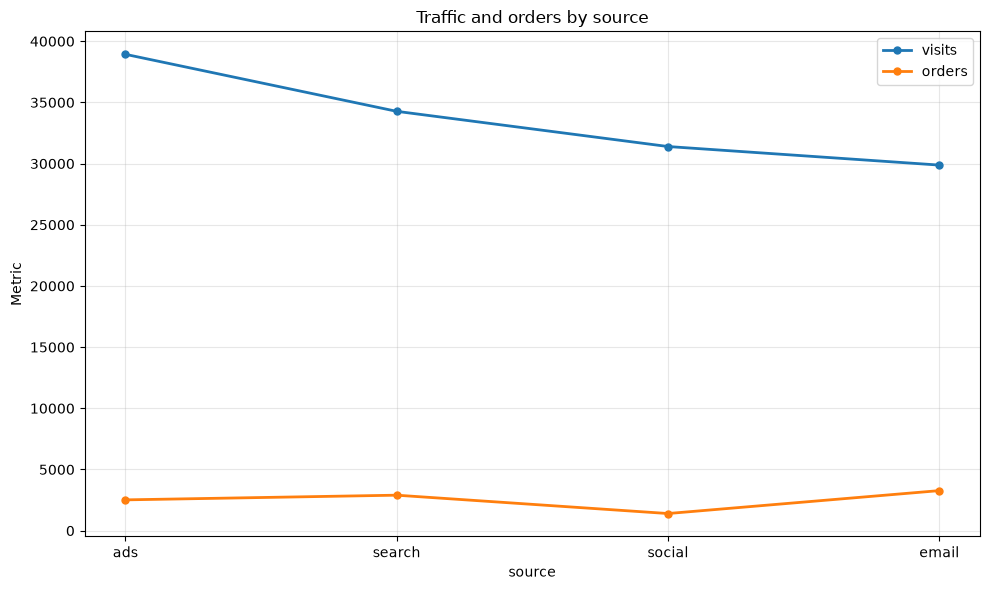

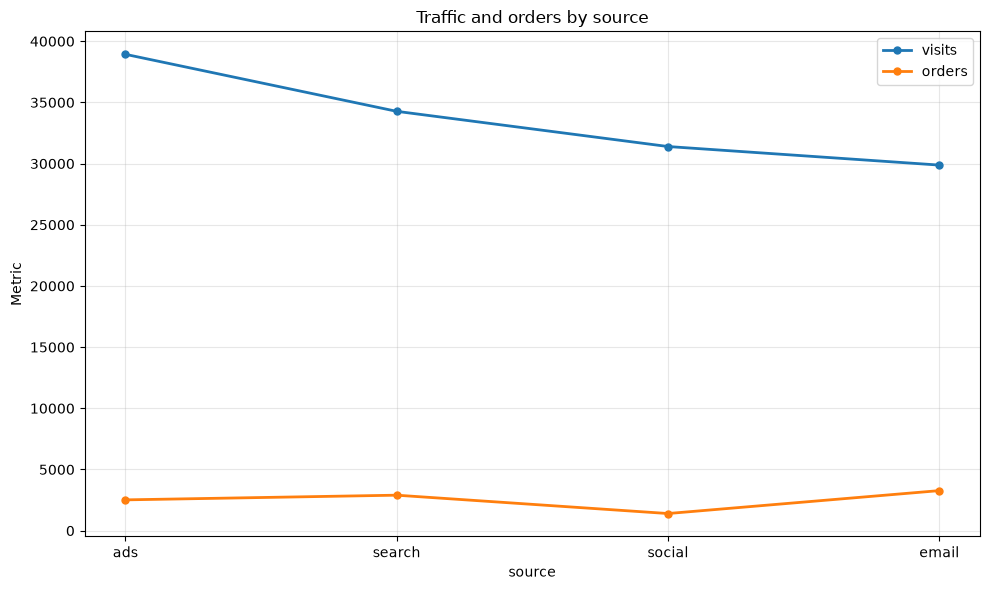

In [4]:
fig, ax = plot_metric_comparison(
    summary,
    x_col="source",
    metrics=["visits", "orders"],
    title="Traffic and orders by source",
)
fig

## 2) 实验报告模板

Use this section to compare variances and highlight which experiment arm is ahead of the baseline.

In [5]:
ab = ab_test_summary(
    df,
    variant_col="channel",
    metric_col="orders",
    baseline_variant="organic",
)
ab

,variant,sample_size,metric_value,uplift
0,email,30,109.066667,0.128665
1,organic,30,96.633333,0.000000
2,paid,30,83.866667,-0.132115
3,social,30,46.633333,-0.517420


In [6]:
funnel = funnel_comparison(
    df.assign(user_id=df.index.astype(str)),
    user_id_col="user_id",
    stage_col="source",
    variant_col="channel",
)
funnel

,variant,stage,user_count,total_users,conversion_rate
0,email,email,30,30,1.0
1,organic,search,30,30,1.0
2,paid,ads,30,30,1.0
3,social,social,30,30,1.0


## 3) 自定义 KPI 监控表

This pattern helps define a monitor table for date-based metric tracking.

In [7]:
kpi = kpi_monitor_table(
    df,
    date_col="date",
    metrics={"visits": "visits", "orders": "orders", "revenue": "revenue"},
    freq="D",
)
kpi.head()

,date,visits,orders,revenue
0,2026-01-01,3167,237,10945.36
1,2026-01-02,3011,224,10348.88
2,2026-01-03,3602,270,12478.16
3,2026-01-04,4357,327,15120.56
4,2026-01-05,4019,302,13973.52


## 4) 归因拆解模板

Evaluate the contribution from each acquisition channel by revenue or conversion impact.

In [8]:
attribution = attribution_breakdown(
    df,
    user_id_col="user_id",
    channel_col="channel",
    value_col="revenue",
    conversion_col="orders",
    method="last_touch",
)
attribution

,channel,converted_users,revenue,revenue_share
0,email,30,192166.32,0.411812
1,organic,30,141893.84,0.304078
2,paid,30,93690.72,0.200779
3,social,30,38885.68,0.083332


## 5) 多指标对比 notebook 复用脚本

This is the reusable container for a growth dashboard snapshot.

In [9]:
growth_report = build_growth_dashboard(
    df,
    date_col="date",
    group_by="source",
    metrics={"visits": "visits", "orders": "orders", "revenue": "revenue"},
    variant_col="channel",
    baseline_variant="organic",
)

for key, value in growth_report.items():
    print(f"{key}: {value.shape}")

growth_report["summary"].head()

summary: (4, 4)
trend: (120, 3)
ab_summary: (4, 4)


,source,visits,orders,revenue
0,ads,38934,2516,93690.72
1,search,34273,2899,141893.84
2,social,31396,1399,38885.68
3,email,29879,3272,192166.32
